In [45]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
import seaborn as sns
from scipy.stats import pearsonr 
from scipy.stats import shapiro 
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from OceanDataStore import OceanDataCatalog 
from nemo_cookbook import NEMODataTree  
from matplotlib.patches import Rectangle


In [18]:
def select_by_lonlat(ds, lon_target, lat_target):
    lat = ds['gphit'].values
    lon = ds['glamt'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return (y_idx, x_idx)


In [2]:
# Open model and config files

catalog = OceanDataCatalog(catalog_name='noc-model-stac')
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1_annual = catalog.open_dataset(id=catalog.Items[2].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
ds1_5day = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')

catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets_annual = {'parent': {'domain': config, 'gridT': ds1_annual}}
dt_global_annual = NEMODataTree.from_datasets(datasets = datasets_annual)
datasets_5day = {'parent': {'domain': config, 'gridT': ds1_5day}}
dt_global_5day = NEMODataTree.from_datasets(datasets = datasets_5day)

# Clip to North Atlantic 
bbox = (-85.0, 0.0, 0.0, 80.0)
dt_annual = dt_global_annual.clip_grid(grid='/gridT', bbox=bbox)
dt_5day = dt_global_5day.clip_grid(grid='/gridT', bbox=bbox)

# Convert to datasets
ds_annual = (dt_annual['/gridT']).dataset
ds_5day = (dt_5day['/gridT']).dataset


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [9]:
## Compute data 

min_region = ds_5day.sel(time_counter = ds_5day['time_counter'].dt.month.isin([2, 3, 4]))
max_region = ds_5day.sel(time_counter = ds_5day['time_counter'].dt.month.isin([8, 9, 10]))
min_temp = ((min_region['tos_con'].groupby('time_counter.year')).min(dim='time_counter')).compute()
max_temp = ((max_region['tos_con'].groupby('time_counter.year')).max(dim='time_counter')).compute()
amplitude = (max_temp - min_temp).compute()
salinity = ds_annual['sos_abs'].compute()

KeyboardInterrupt: 

In [13]:
## Saving 

amplitude.to_netcdf('amplitude_ts_0.25.nc')
salinity.to_netcdf('salinity_ts_0.25.nc')

In [61]:
salinity = xr.open_dataset('salinity_ts_0.25.nc')
amplitude = xr.open_dataset('amplitude_ts_0.25.nc')

In [4]:
## Compute Correlation coefficients and p values 

ny, nx = amplitude.sizes['j'], amplitude.sizes['i']
r_data = np.full((ny, nx), np.nan, dtype = np.float32)
p_data = np.full((ny, nx), np.nan, dtype = np.float32)

print('starting loop')
for y_idx in range (ny):
    for x_idx in range (nx):
        amp_ts = amplitude.isel(j=y_idx, i=x_idx)['tos_con'].values
        sal_ts = salinity.isel(j=y_idx, i=x_idx)['sos_abs'].values
        try:
            r, p = pearsonr(sal_ts, amp_ts)
            r_data[y_idx, x_idx] = r
            p_data[y_idx, x_idx] = p
        except:
            r_data[y_idx, x_idx] = np.nan
            p_data[y_idx, x_idx] = np.nan
    print(y_idx)


starting loop
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273


In [5]:
## Converting to dataarray

r_da = xr.DataArray(data = r_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='correlation',
        attrs={'description': 'Correlation coefficient between amplitude and salinity'})

pval_da = xr.DataArray(data = p_data, dims=['j', 'i'], 
        coords={ 'j': amplitude['j'],
        'i': amplitude['i'], 'gphit': (('j', 'i'), amplitude['gphit'].values),
        'glamt': (('j', 'i'), amplitude['glamt'].values)}, name='p-value',
        attrs={'description': 'P-value for correlation coefficient between amplitude and salinity'})

In [7]:
## Saving correlation coefficient and p-value 

r_da.to_netcdf('pearsons_0.25.nc')
pval_da.to_netcdf('pearsons_pval_0.25.nc')

In [64]:
## Start from here in future 

r_da = (xr.open_dataset('pearsons_0.25.nc'))['correlation']
pval_da = (xr.open_dataset('pearsons_pval_0.25.nc'))['p-value']

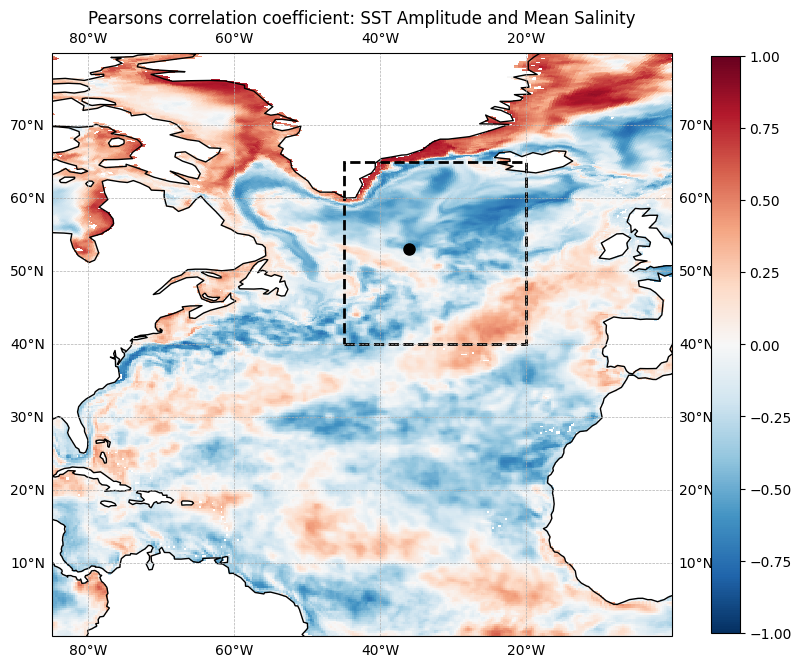

In [14]:
fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
title = ax.set_title('Pearsons correlation coefficient: SST Amplitude and Mean Salinity')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

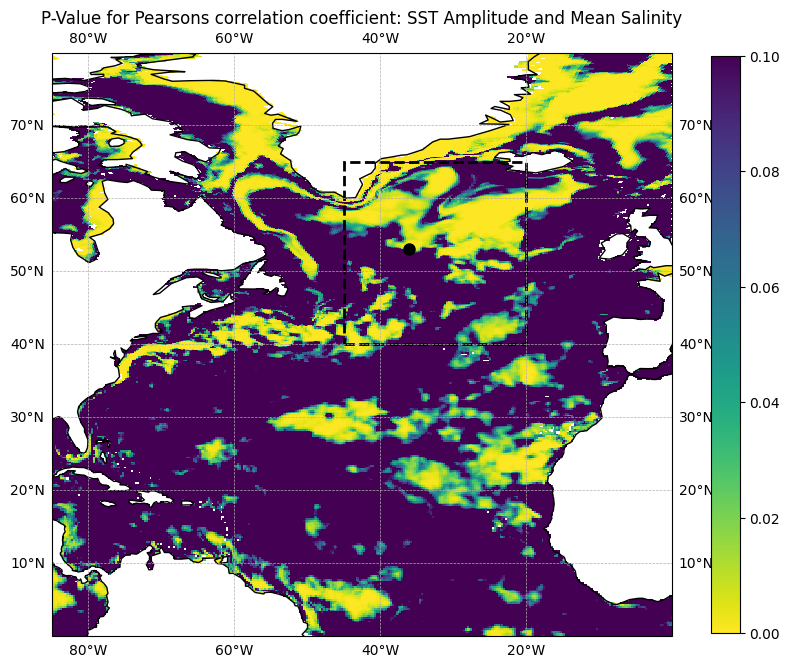

In [15]:
fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})

im = ax.pcolormesh(pval_da['glamt'], pval_da['gphit'], pval_da, cmap='viridis_r', transform=ccrs.PlateCarree(), vmin = 0.00, vmax = 0.10)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
title = ax.set_title('P-Value for Pearsons correlation coefficient: SST Amplitude and Mean Salinity')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

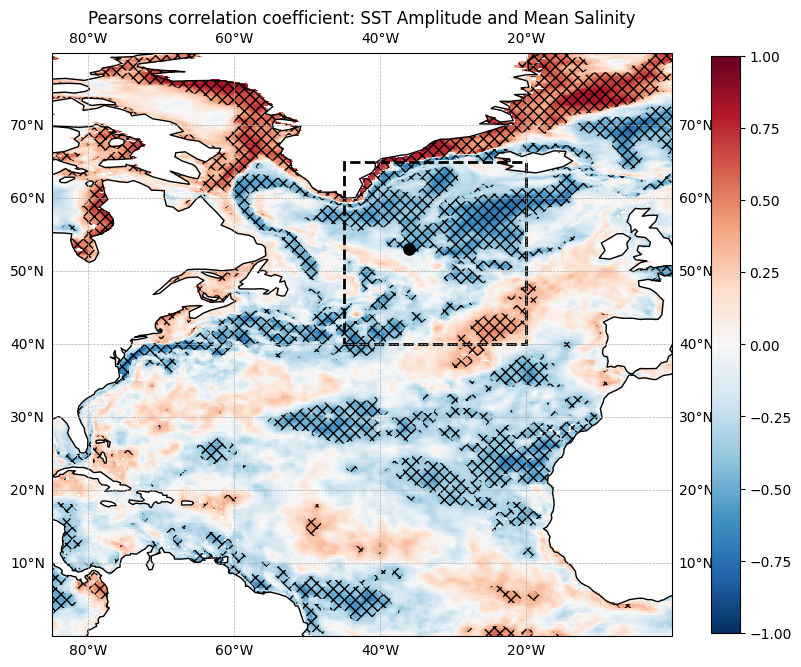

In [36]:
## Hatched Plot 
sig_mask = pval_da < 0.05

fig, ax = plt.subplots(figsize = (10,25), subplot_kw={'projection': ccrs.PlateCarree()})
im = ax.pcolormesh(r_da['glamt'], r_da['gphit'], r_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin = -1, vmax = 1)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
significance = ax.contourf(sig_mask['glamt'], sig_mask['gphit'], sig_mask, levels=[0.5, 1.0], colors='none', hatches=['xxx'], transform=ccrs.PlateCarree())
title = ax.set_title('Pearsons correlation coefficient: SST Amplitude and Mean Salinity')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, shrink = 0.3)

In [16]:
years = np.arange(1990, 2025)

x index = 239
y index = 258


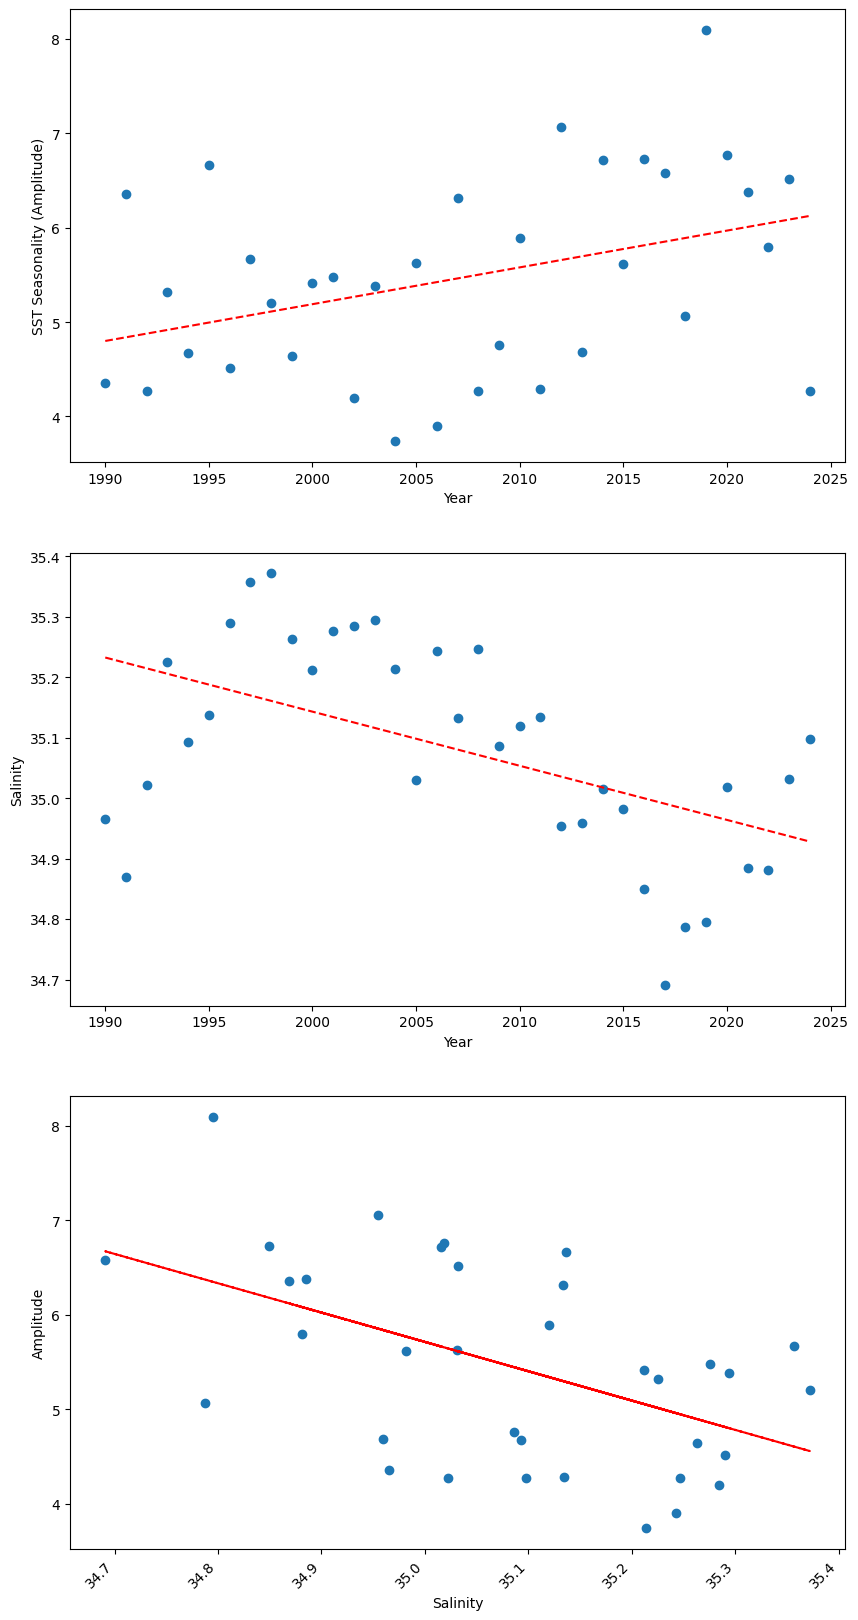

P-value for Shapiro-Wilk test - Amplitude: 0.19834983909170228
P-value for Shapiro-Wilk test - Salinity: 0.4484635349866757


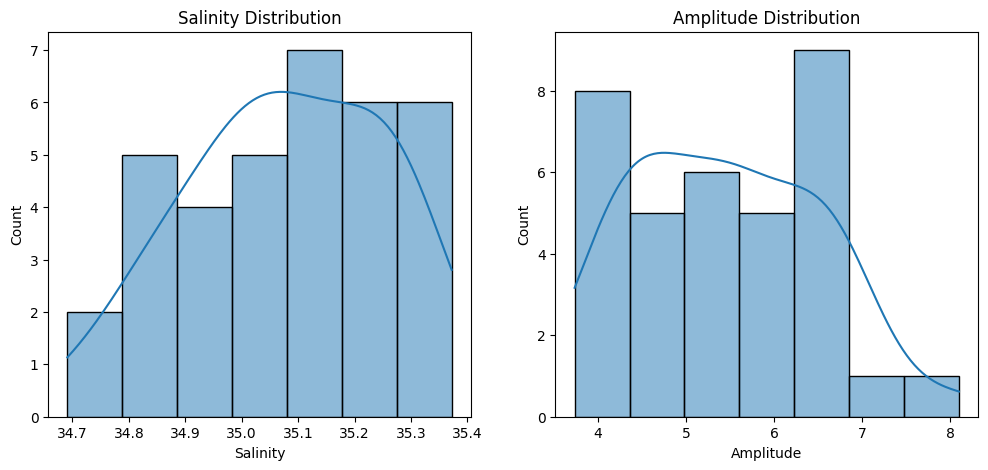

In [51]:
## Consider 25W, 55N

j_idx, i_idx = select_by_lonlat(amplitude, -25.0, 55.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 260
y index = 95


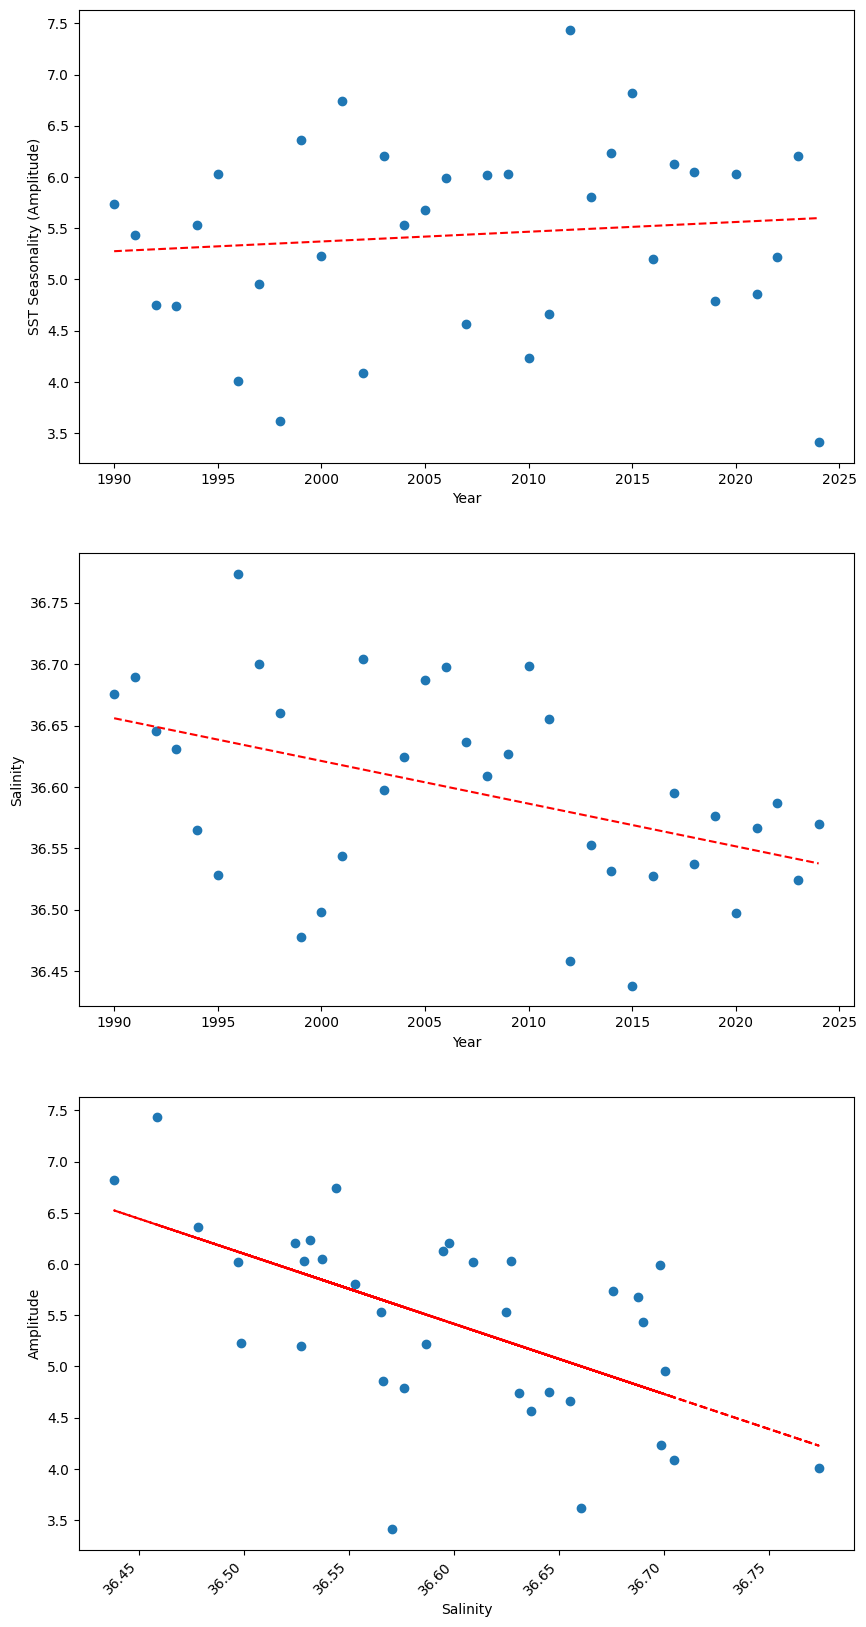

P-value for Shapiro-Wilk test - Amplitude: 0.6105035364639091
P-value for Shapiro-Wilk test - Salinity: 0.807615183894069


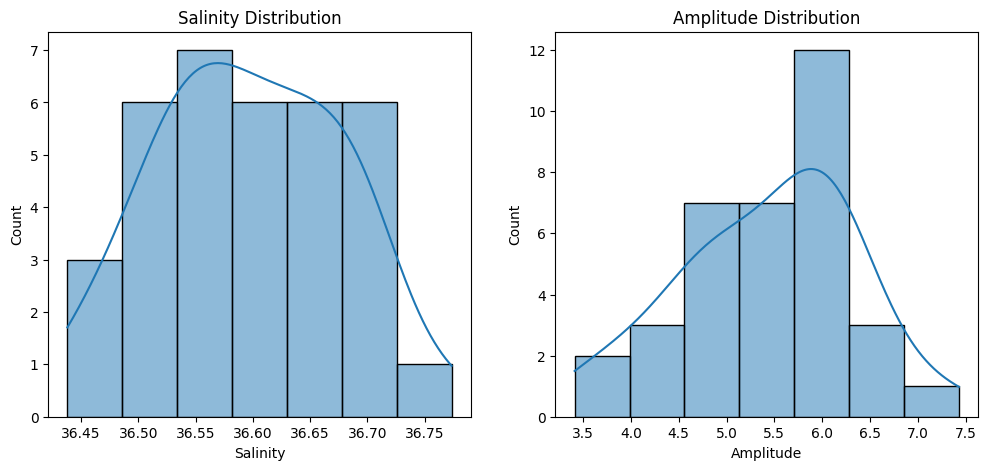

In [52]:
## Consider 20W, 24N

j_idx, i_idx = select_by_lonlat(amplitude, -20.0, 23.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 285
y index = 363


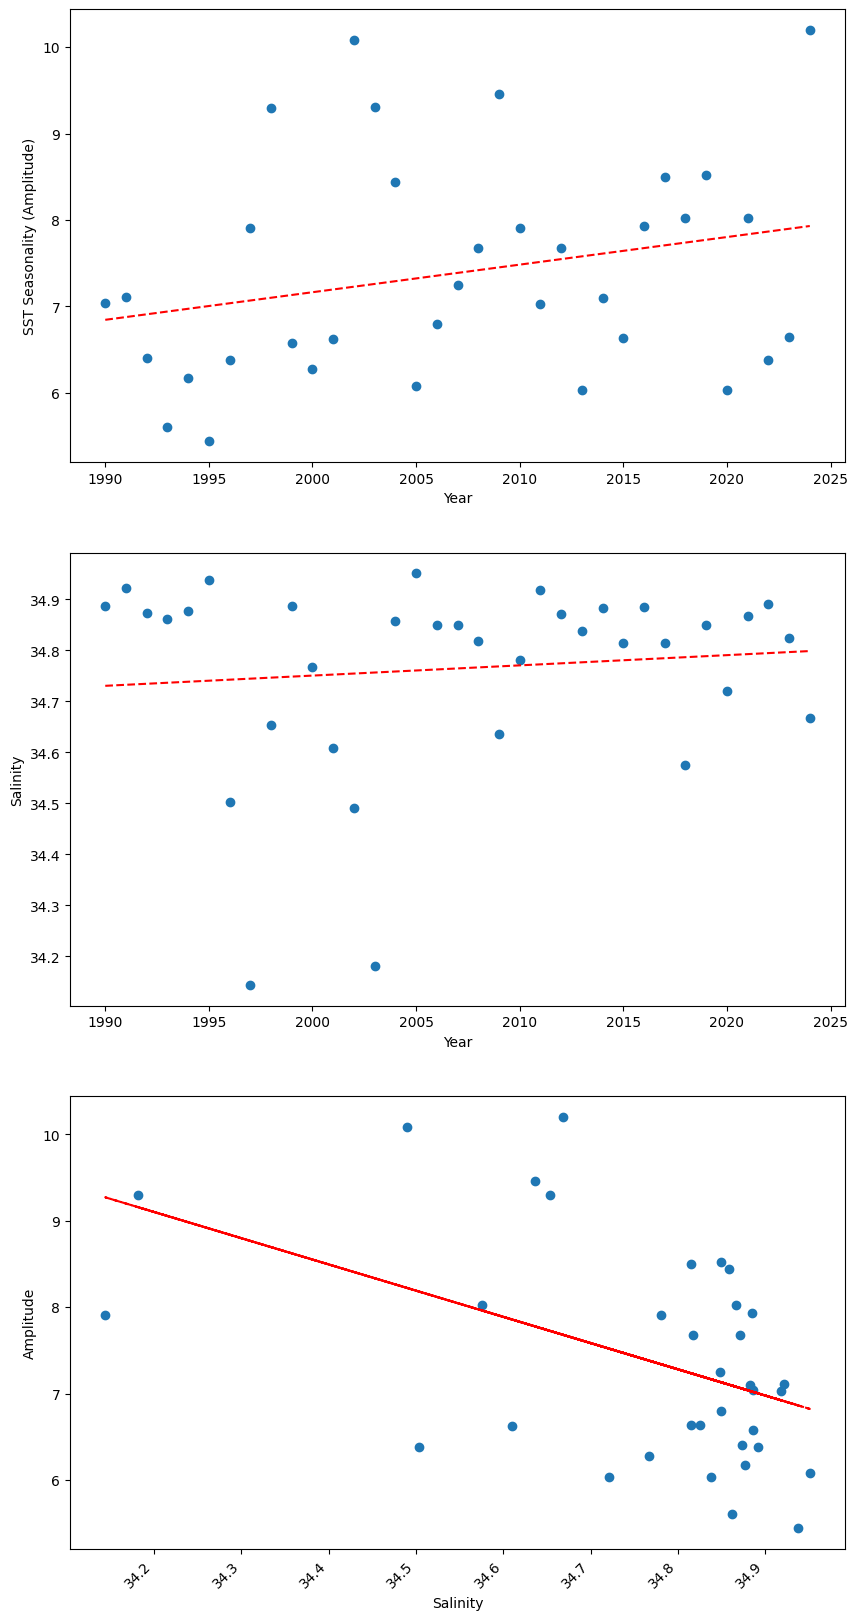

P-value for Shapiro-Wilk test - Amplitude: 0.0702744991828266
P-value for Shapiro-Wilk test - Salinity: 3.152923946249028e-06


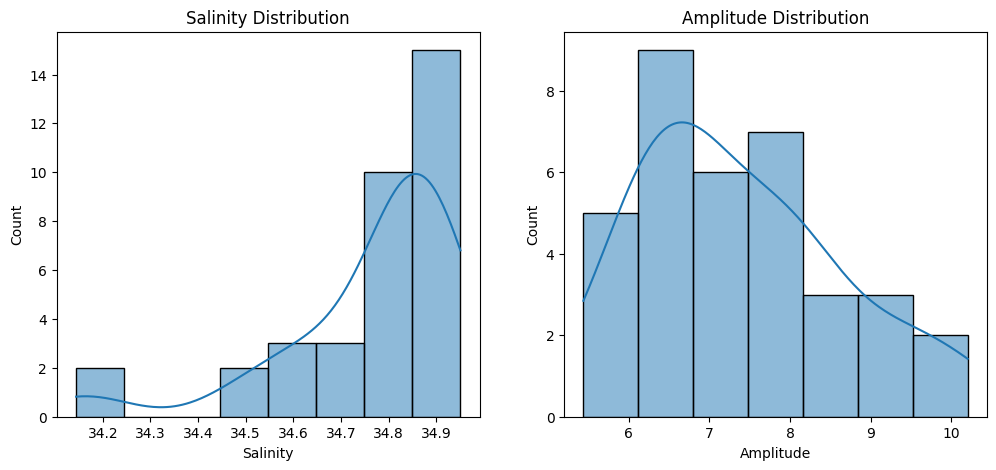

In [53]:
## Consider 8W, 70N

j_idx, i_idx = select_by_lonlat(amplitude, -8.0, 70.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 148
y index = 377


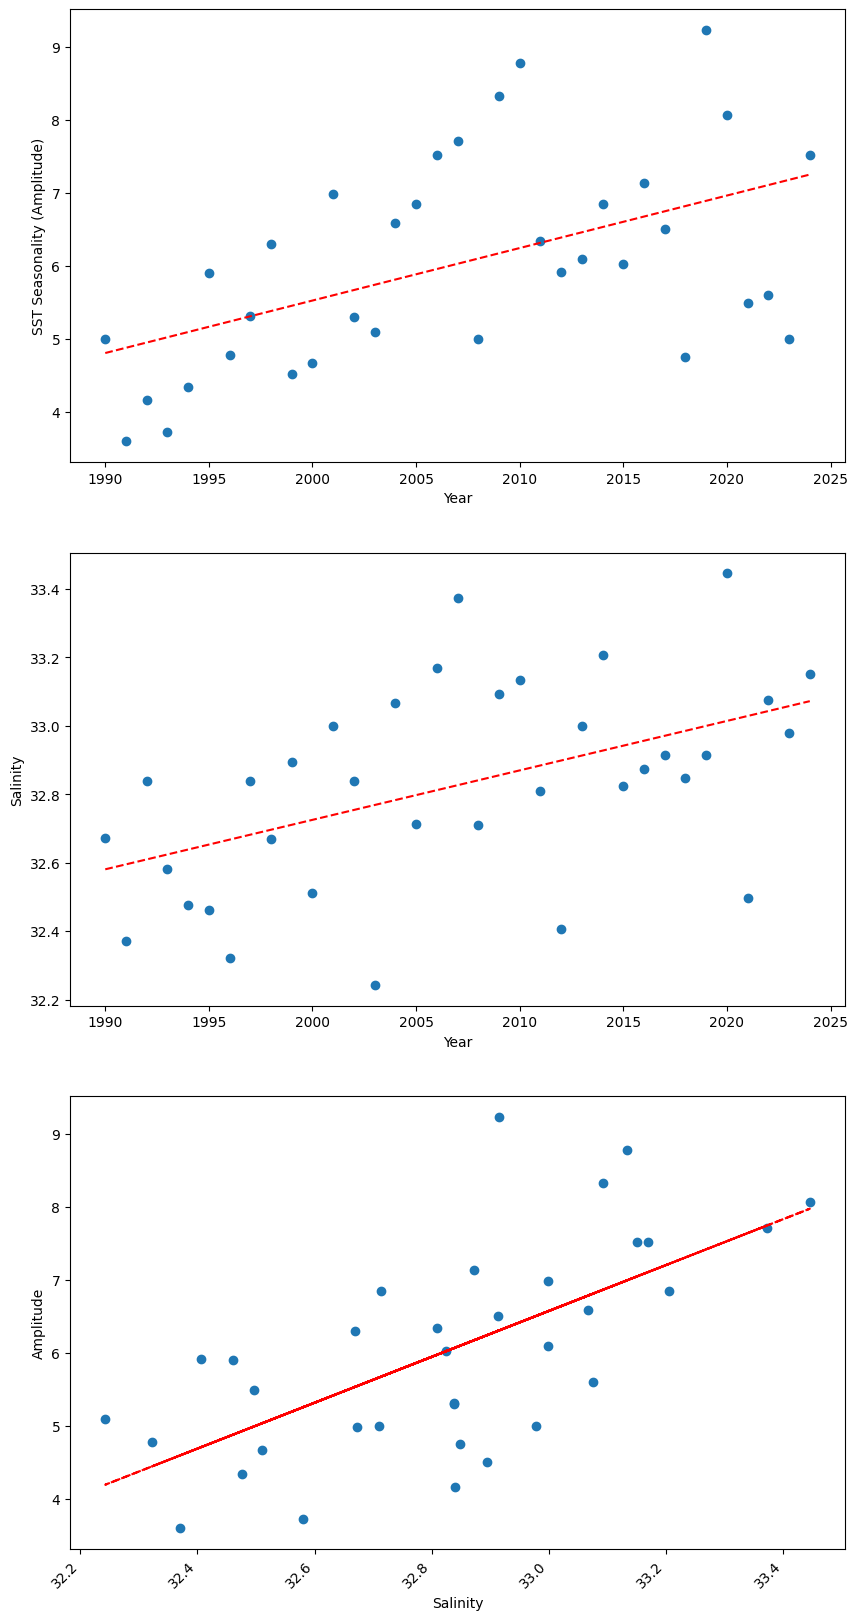

P-value for Shapiro-Wilk test - Amplitude: 0.6307610535188248
P-value for Shapiro-Wilk test - Salinity: 0.78877539057959


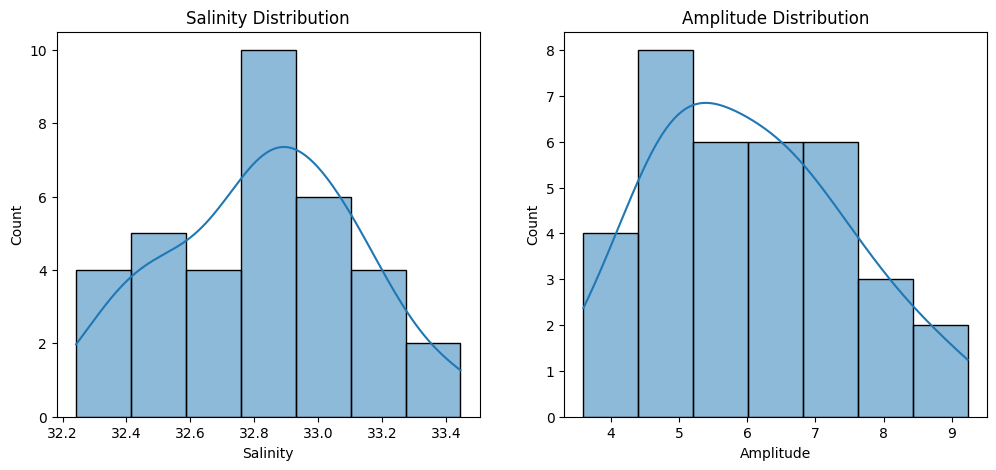

In [55]:
## Consider 58W, 70N 

j_idx, i_idx = select_by_lonlat(amplitude, -58.0, 70.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 119
y index = 304


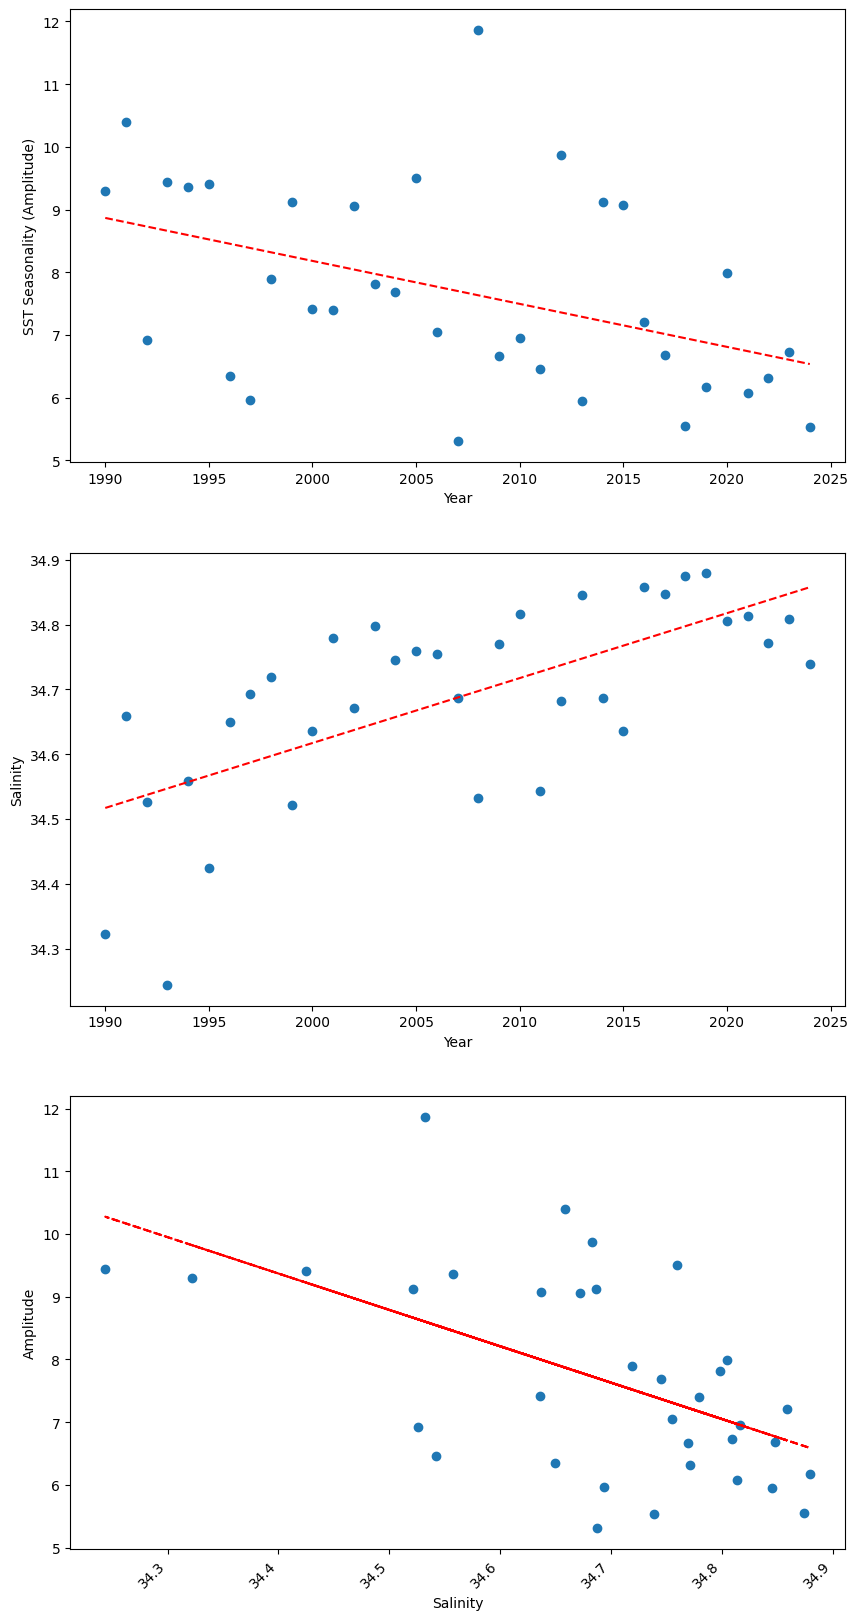

P-value for Shapiro-Wilk test - Amplitude: 0.0628949889728822
P-value for Shapiro-Wilk test - Salinity: 0.005129858511484582


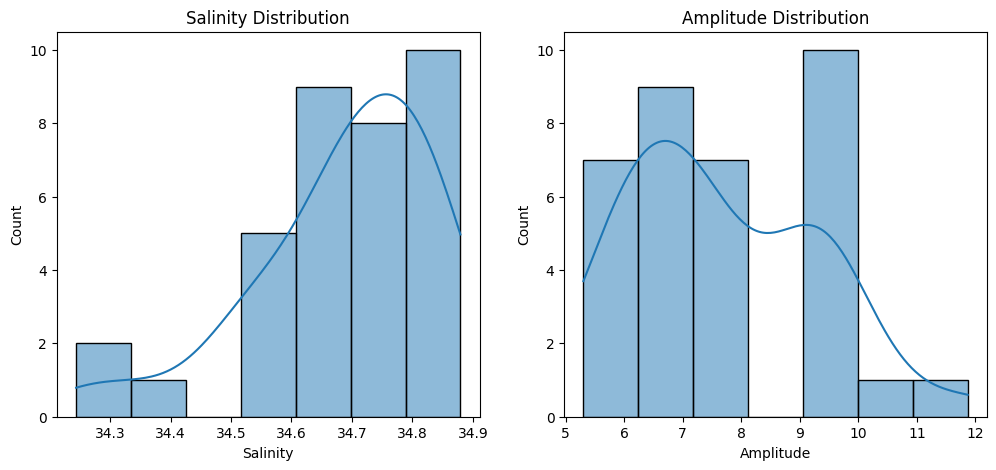

In [56]:
## Consider 59W, 60N

j_idx, i_idx = select_by_lonlat(amplitude, -59.0, 60.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 101
y index = 187


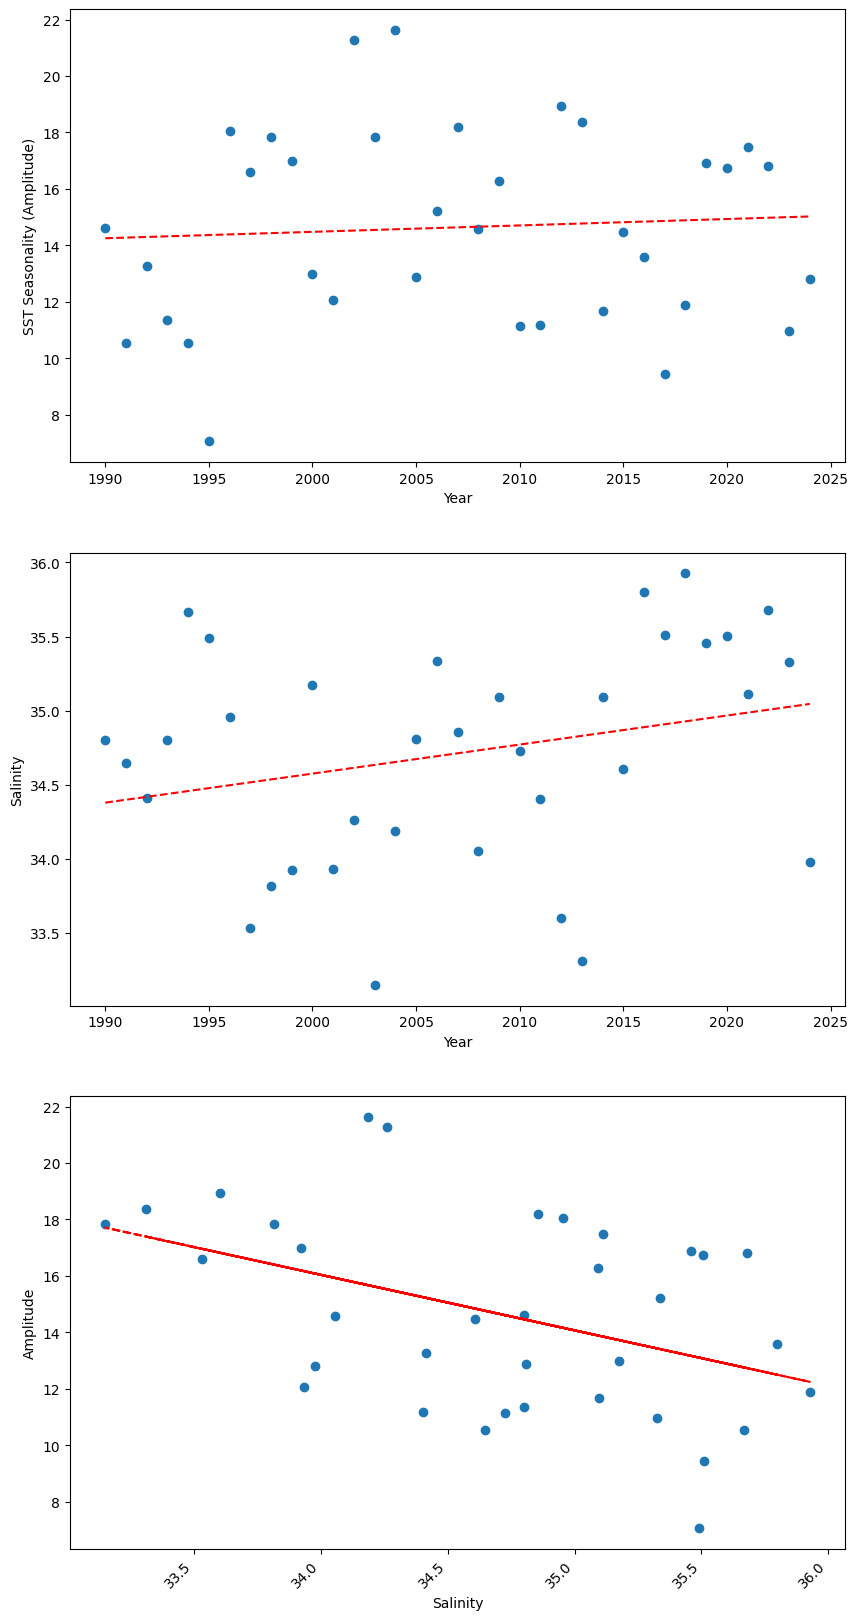

P-value for Shapiro-Wilk test - Amplitude: 0.5194300365546739
P-value for Shapiro-Wilk test - Salinity: 0.3191200765282103


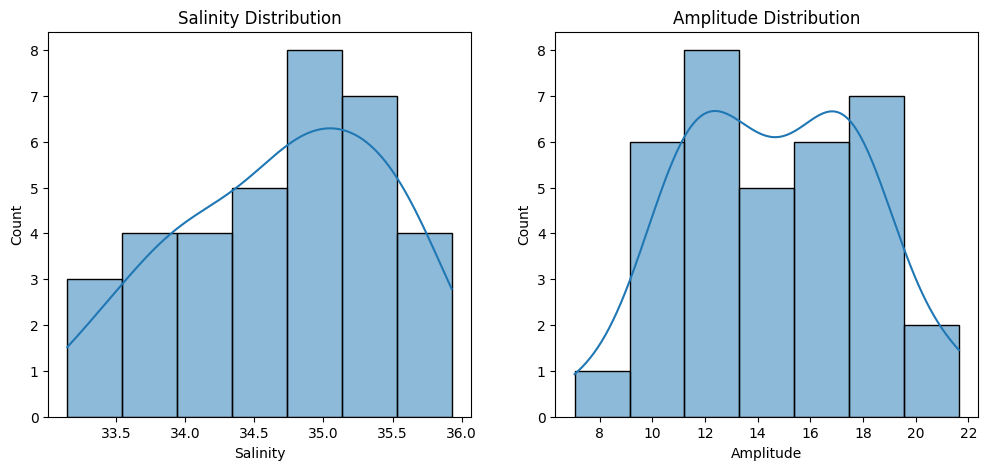

In [57]:
## 60W, 42N

j_idx, i_idx = select_by_lonlat(amplitude, -60.0, 42.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 160
y index = 126


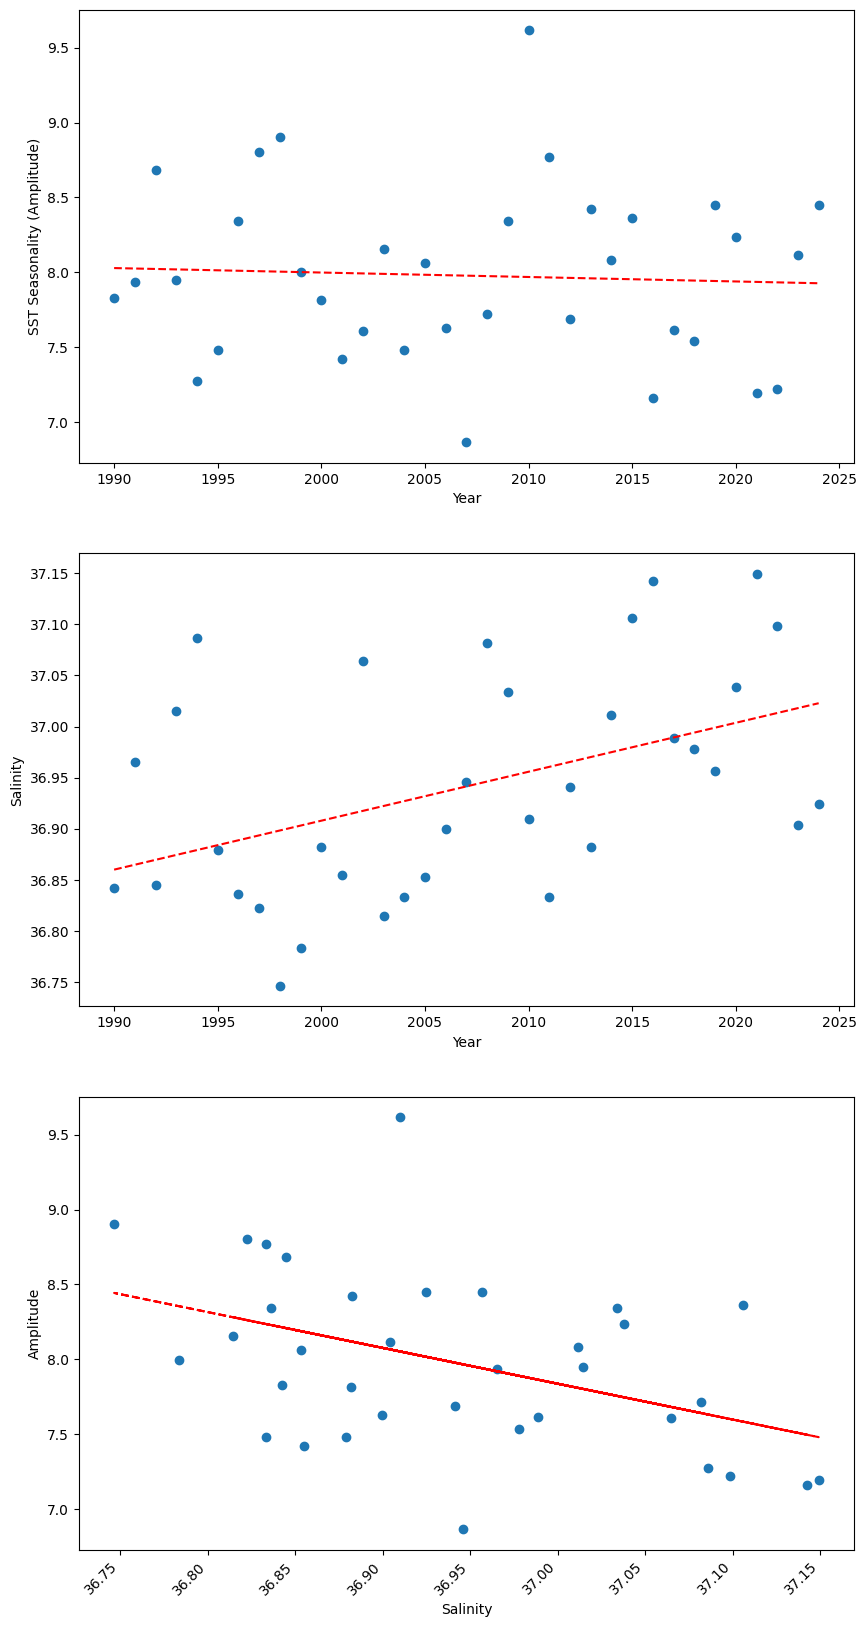

P-value for Shapiro-Wilk test - Amplitude: 0.7273557448069129
P-value for Shapiro-Wilk test - Salinity: 0.21403235108101953


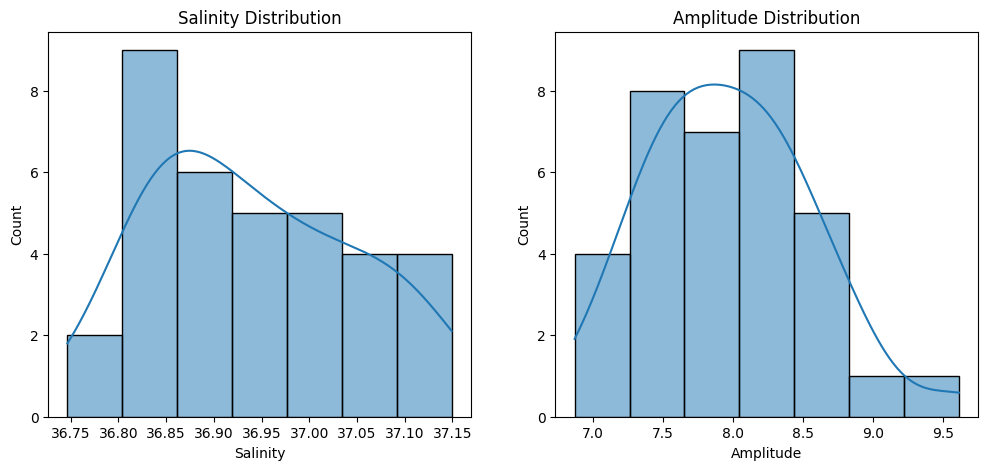

In [58]:
## 45W, 30N

j_idx, i_idx = select_by_lonlat(amplitude, -45.0, 30.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 240
y index = 184


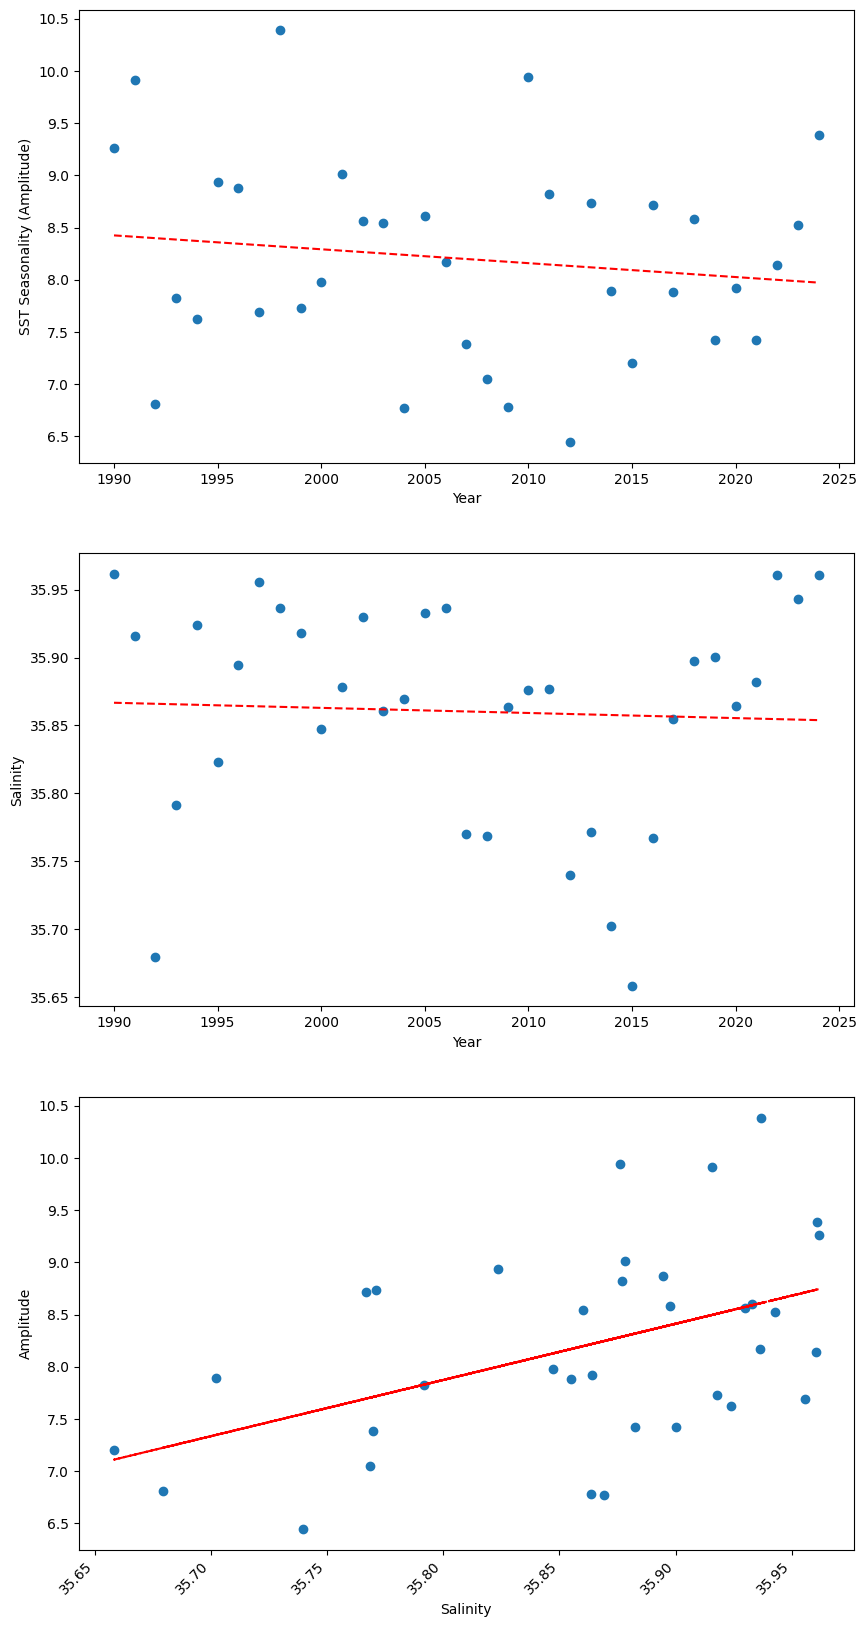

P-value for Shapiro-Wilk test - Amplitude: 0.7709990416287457
P-value for Shapiro-Wilk test - Salinity: 0.006661570299671122


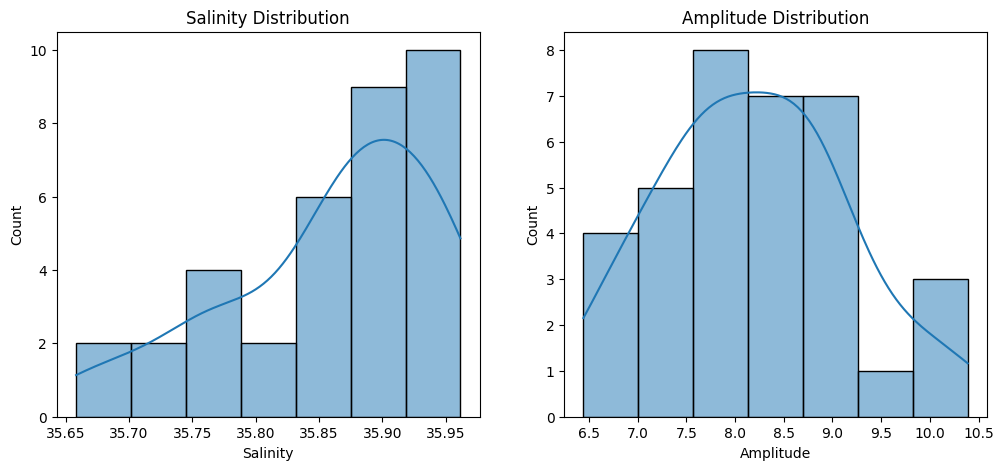

In [59]:
## 25W, 42N

j_idx, i_idx = select_by_lonlat(amplitude, -25.0, 42.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 160
y index = 20


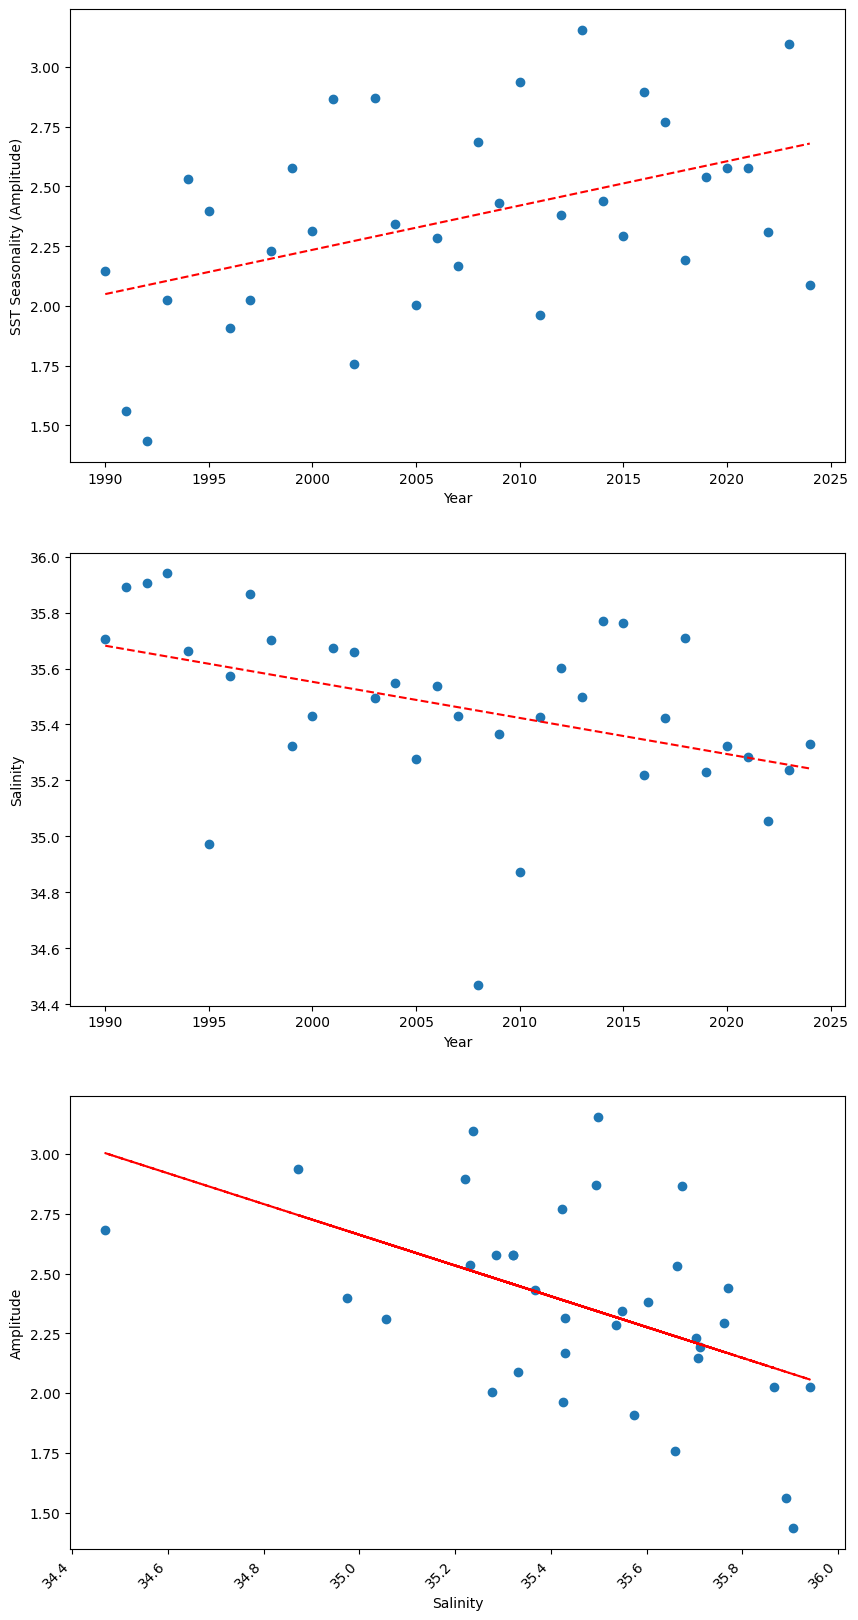

P-value for Shapiro-Wilk test - Amplitude: 0.9480118301536065
P-value for Shapiro-Wilk test - Salinity: 0.07328813216860151


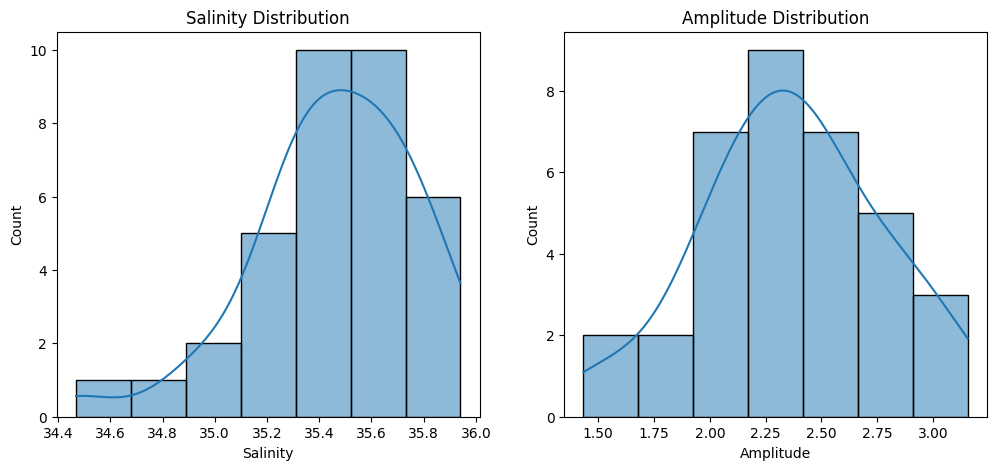

In [60]:
## 45W, 5N

j_idx, i_idx = select_by_lonlat(amplitude, -45.0, 5.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()

x index = 263
y index = 291


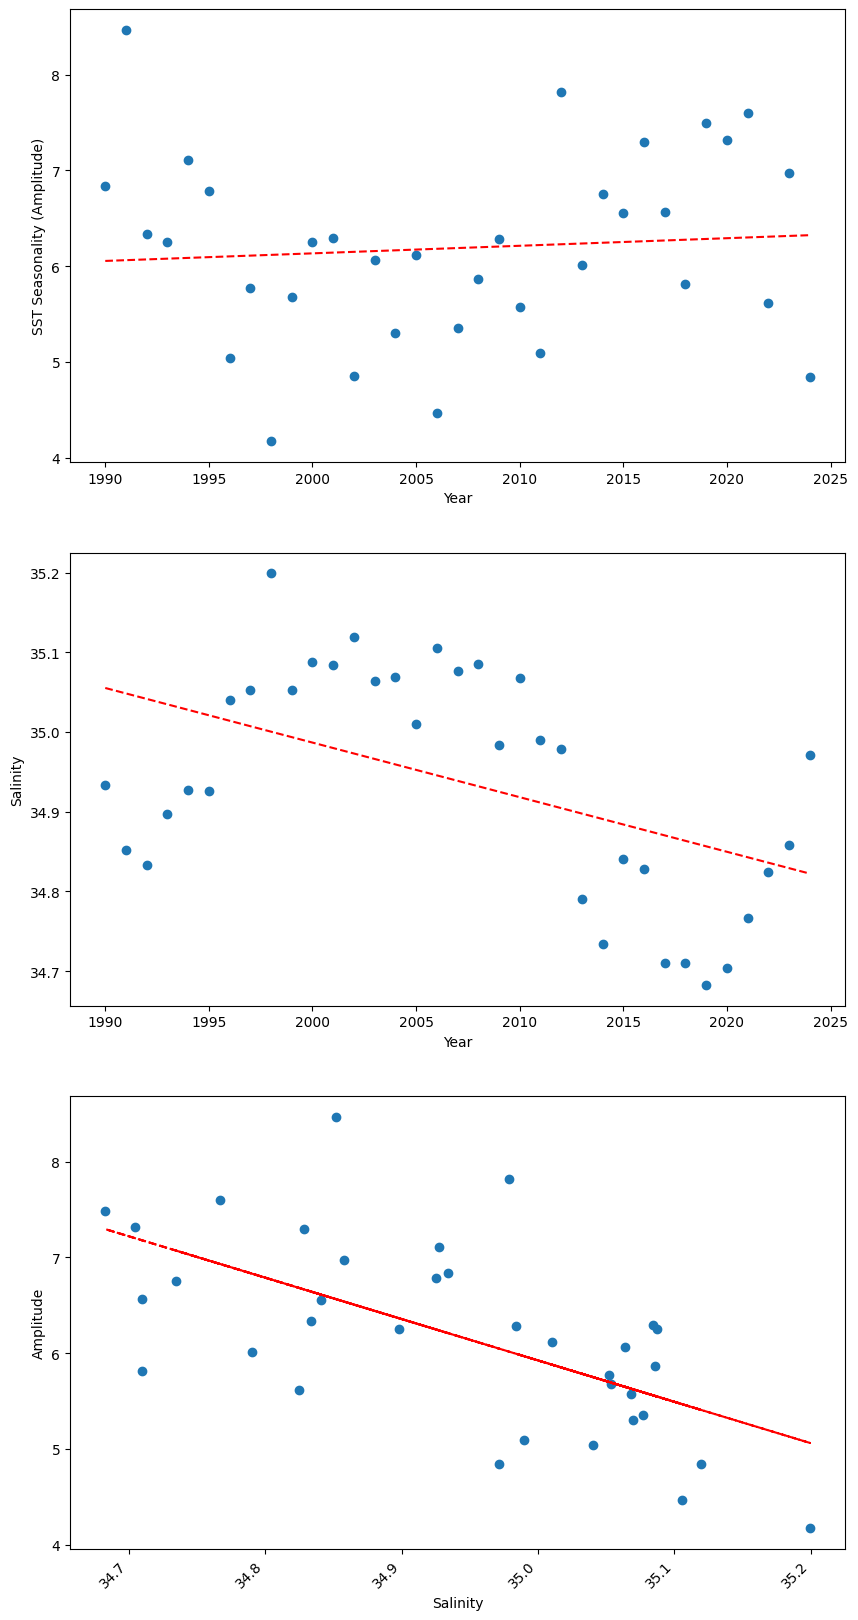

P-value for Shapiro-Wilk test - Amplitude: 0.9996698047349571
P-value for Shapiro-Wilk test - Salinity: 0.07012714726502361


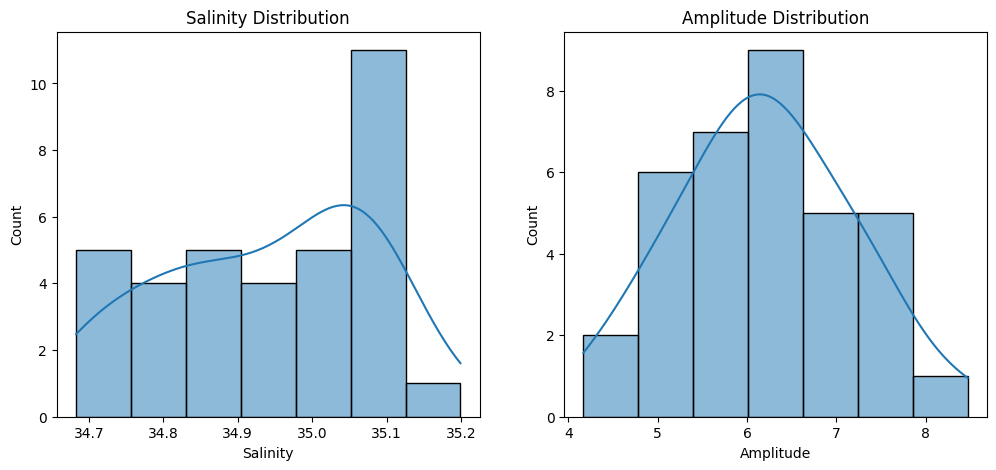

In [65]:
## Consider 18W, 60N

j_idx, i_idx = select_by_lonlat(amplitude, -18.0, 60.0)
amplitude_ts = amplitude.isel(j=j_idx, i=i_idx)['tos_con'].values
salinity_ts = salinity.isel(j=j_idx, i=i_idx)['sos_abs'].values

fig, ax = plt.subplots(3, 1, figsize = (10, 20))
ax0 = ax[0]
ax1 = ax[1]
ax2 = ax[2]

ax0.scatter(years, amplitude_ts)
z = np.polyfit(years, amplitude_ts, 1)
p = np.poly1d(z)
ax0.plot(years ,p(years),"r--")
ax0.set_xlabel('Year')
ax0.set_ylabel('SST Seasonality (Amplitude)')

ax1.scatter(years, salinity_ts)
z = np.polyfit(years, salinity_ts, 1)
p = np.poly1d(z)
ax1.plot(years ,p(years),"r--")
ax1.set_xlabel('Year')
ax1.set_ylabel('Salinity')

ax2.scatter(salinity_ts, amplitude_ts)
z = np.polyfit(salinity_ts, amplitude_ts, 1)
p = np.poly1d(z)
ax2.plot(salinity_ts ,p(salinity_ts),"r--")
ax2.set_xlabel('Salinity')
ax2.set_ylabel('Amplitude')

plt.xticks(rotation=45, ha='right')
plt.show()

print(f'P-value for Shapiro-Wilk test - Amplitude: {shapiro(amplitude_ts).pvalue}')
print(f'P-value for Shapiro-Wilk test - Salinity: {shapiro(salinity_ts).pvalue}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(salinity_ts, kde=True, ax=ax[0])
ax[0].set_title("Salinity Distribution")
ax[0].set_xlabel("Salinity")
sns.histplot(amplitude_ts, kde=True, ax=ax[1])
ax[1].set_title("Amplitude Distribution")
ax[1].set_xlabel("Amplitude")
plt.show()